In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge,Lasso, ElasticNet

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error

In [3]:
np.random.seed(42)

X= np.linspace(-3,3,30)
X

array([-3.        , -2.79310345, -2.5862069 , -2.37931034, -2.17241379,
       -1.96551724, -1.75862069, -1.55172414, -1.34482759, -1.13793103,
       -0.93103448, -0.72413793, -0.51724138, -0.31034483, -0.10344828,
        0.10344828,  0.31034483,  0.51724138,  0.72413793,  0.93103448,
        1.13793103,  1.34482759,  1.55172414,  1.75862069,  1.96551724,
        2.17241379,  2.37931034,  2.5862069 ,  2.79310345,  3.        ])

In [4]:
X.reshape(-1,1)

array([[-3.        ],
       [-2.79310345],
       [-2.5862069 ],
       [-2.37931034],
       [-2.17241379],
       [-1.96551724],
       [-1.75862069],
       [-1.55172414],
       [-1.34482759],
       [-1.13793103],
       [-0.93103448],
       [-0.72413793],
       [-0.51724138],
       [-0.31034483],
       [-0.10344828],
       [ 0.10344828],
       [ 0.31034483],
       [ 0.51724138],
       [ 0.72413793],
       [ 0.93103448],
       [ 1.13793103],
       [ 1.34482759],
       [ 1.55172414],
       [ 1.75862069],
       [ 1.96551724],
       [ 2.17241379],
       [ 2.37931034],
       [ 2.5862069 ],
       [ 2.79310345],
       [ 3.        ]])

In [5]:
y= 0.5 * X**3 - X**2 + X + np.random.normal(0,3,size=X.shape)
y

array([-2.40098575e+01, -2.19044194e+01, -1.59804860e+01, -1.02061165e+01,
       -1.27204805e+01, -1.03278363e+01, -2.83321317e+00, -3.52542553e+00,
       -5.77791350e+00, -1.54188402e+00, -3.59163485e+00, -2.83556312e+00,
       -1.28084238e-01, -6.16144474e+00, -5.28945685e+00, -1.59356233e+00,
       -2.80951718e+00,  1.26163576e+00, -2.33444986e+00, -3.76917975e+00,
        4.97673638e+00,  7.50389693e-02,  1.21461873e+00, -2.88888641e+00,
        2.65761171e-01,  2.91202481e+00, -1.01307662e-05,  5.67371343e+00,
        4.08485666e+00,  6.62491875e+00])

In [17]:
X = np.linspace(-3, 3, 30).reshape(-1, 1)
y = 0.5 * X**3 - X**2 + X + np.random.normal(0, 3, size=X.shape)

In [18]:
X_train, X_test, y_train, y_test = train_test_split( X, y , test_size=0.3 , random_state=42)

In [19]:
X_train.shape , y_train.shape

((21, 1), (21, 1))

* **In Ridge, Lasso, and Elastic Net, alpha means λ (regularization strength), NOT learning rate.**

In [ ]:
def fit_and_plot(model, title):

    model.fit(X_train, y_train)

    X_plot = np.linspace(-3,3,200).reshape(-1,1)               
    y_plot = model.predict(X_plot)

    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error( y_test , model.predict(X_test))

    plt.scatter(X_train , y_train ,label ="Train data")
    plt.scatter( X_test , y_test , label="Test data")
    plt.plot(X_plot, y_plot, linewidth=2, label= " Model pridection")
    plt.title(f"{title}\n train MSE= {train_mse:.2f}, Test MSE= {test_mse: .2f}")
    plt.legend()
    plt.show

# Normal Model

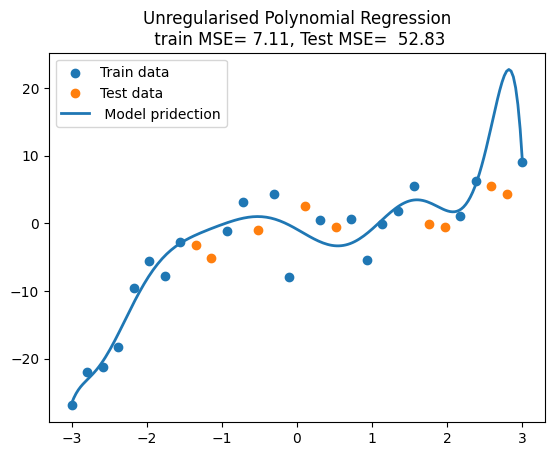

In [23]:
normal_model = Pipeline([
    ("poly", PolynomialFeatures(degree=10)),
    ("scalar", StandardScaler()),
    ("lr", LinearRegression())
])
fit_and_plot(normal_model, "Unregularised Polynomial Regression")

* Test MSE is high, model is overfitting

# Ridge (L2)

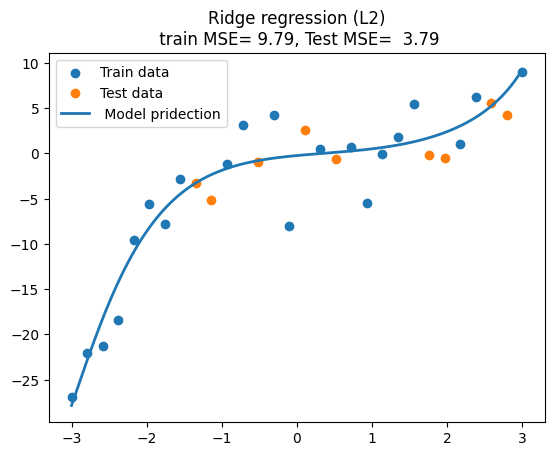

In [24]:
ridge_model= Pipeline([
    ("poly", PolynomialFeatures(degree=10)),
    ("scalar", StandardScaler()),
    ("Ridge", Ridge(alpha=0.9))
])

fit_and_plot(ridge_model, "Ridge regression (L2)")

# Lasso (L1)

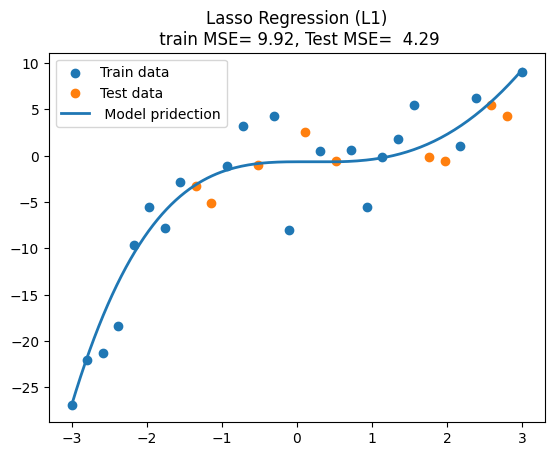

In [25]:
lasso_model = Pipeline([
    ("poly", PolynomialFeatures(degree=10)),
    ("scalar", StandardScaler()),
    ("Lasso", Lasso( alpha=0.5, max_iter= 10000))
])
fit_and_plot( lasso_model , "Lasso Regression (L1)")

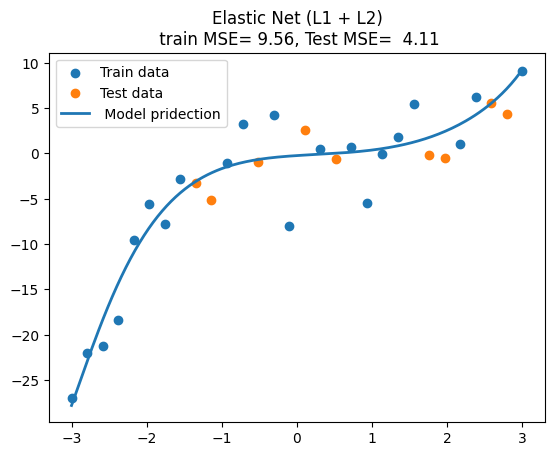

In [26]:
elastic_model = Pipeline([
    ( "poly" , PolynomialFeatures(degree= 10)),
    ("scalar", StandardScaler()),
    ("elastic", ElasticNet(alpha=0.05 , l1_ratio= 0.5 , max_iter= 10000))
])

fit_and_plot(elastic_model, "Elastic Net (L1 + L2)")

In [27]:
models = {
    "Normal": normal_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "ElasticNet": elastic_model
}

for name, model in models.items():
    coef = model.named_steps[list(model.named_steps.keys())[-1]].coef_
    print(f"{name} – number of non-zero coefficients: {np.sum(coef != 0)}")


Normal – number of non-zero coefficients: 10
Ridge – number of non-zero coefficients: 10
Lasso – number of non-zero coefficients: 3
ElasticNet – number of non-zero coefficients: 8


---

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [30]:
alphas = np.logspace(-4, 2, 50)
alphas

array([1.00000000e-04, 1.32571137e-04, 1.75751062e-04, 2.32995181e-04,
       3.08884360e-04, 4.09491506e-04, 5.42867544e-04, 7.19685673e-04,
       9.54095476e-04, 1.26485522e-03, 1.67683294e-03, 2.22299648e-03,
       2.94705170e-03, 3.90693994e-03, 5.17947468e-03, 6.86648845e-03,
       9.10298178e-03, 1.20679264e-02, 1.59985872e-02, 2.12095089e-02,
       2.81176870e-02, 3.72759372e-02, 4.94171336e-02, 6.55128557e-02,
       8.68511374e-02, 1.15139540e-01, 1.52641797e-01, 2.02358965e-01,
       2.68269580e-01, 3.55648031e-01, 4.71486636e-01, 6.25055193e-01,
       8.28642773e-01, 1.09854114e+00, 1.45634848e+00, 1.93069773e+00,
       2.55954792e+00, 3.39322177e+00, 4.49843267e+00, 5.96362332e+00,
       7.90604321e+00, 1.04811313e+01, 1.38949549e+01, 1.84206997e+01,
       2.44205309e+01, 3.23745754e+01, 4.29193426e+01, 5.68986603e+01,
       7.54312006e+01, 1.00000000e+02])

## Ridge with cross validation

In [31]:
ridge_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=10)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_param_grid = {
    "ridge__alpha": alphas
}

ridge_cv = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_cv.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_cv.best_params_["ridge__alpha"])


Best Ridge alpha: 4.498432668969444


In [32]:
best_ridge = ridge_cv.best_estimator_

print("Train MSE:", mean_squared_error(y_train, best_ridge.predict(X_train)))
print("Test MSE :", mean_squared_error(y_test, best_ridge.predict(X_test)))


Train MSE: 11.256557289015564
Test MSE : 2.9982911986306444


## Lasso regression with cross validation

In [33]:
lasso_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=10)),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

lasso_param_grid = {
    "lasso__alpha": alphas
}

lasso_cv = GridSearchCV(
    lasso_pipeline,
    lasso_param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_cv.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_cv.best_params_["lasso__alpha"])


c:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.441e+01, tolerance: 1.382e-01
  model = cd_fast.enet_coordinate_descent(
c:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.496e+01, tolerance: 1.266e-01
  model = cd_fast.enet_coordinate_descent(
c:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.754e+01, tolerance: 1.639e-01
  model = cd_fast.enet_

Best Lasso alpha: 0.35564803062231287


## ElasticNet with cross validation

In [34]:
elastic_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=10)),
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(max_iter=10000))
])

elastic_param_grid = {
    "elastic__alpha": alphas,
    "elastic__l1_ratio": [0.2, 0.5, 0.8]
}

elastic_cv = GridSearchCV(
    elastic_pipeline,
    elastic_param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

elastic_cv.fit(X_train, y_train)

print("Best ElasticNet params:", elastic_cv.best_params_)


c:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.221e+01, tolerance: 1.382e-01
  model = cd_fast.enet_coordinate_descent(
c:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.944e+01, tolerance: 1.266e-01
  model = cd_fast.enet_coordinate_descent(
c:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.983e+01, tolerance: 1.639e-01
  model = cd_fast.enet_

Best ElasticNet params: {'elastic__alpha': np.float64(0.20235896477251575), 'elastic__l1_ratio': 0.8}


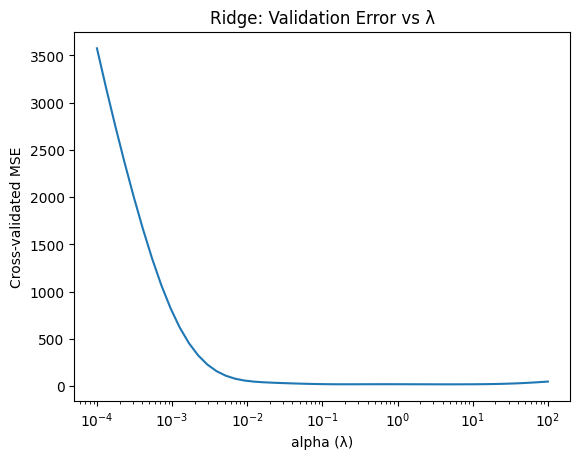

In [35]:
ridge_scores = -ridge_cv.cv_results_["mean_test_score"]

plt.plot(alphas, ridge_scores)
plt.xscale("log")
plt.xlabel("alpha (λ)")
plt.ylabel("Cross-validated MSE")
plt.title("Ridge: Validation Error vs λ")
plt.show()


Left side (small λ) → high variance

Right side (large λ) → high bias

Minimum → optimal tradeoff

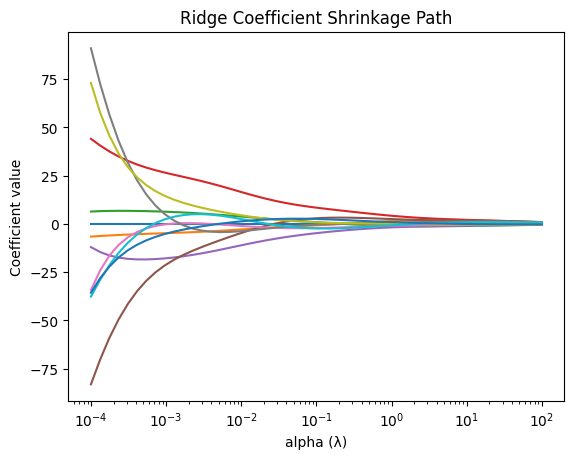

In [36]:
coefs = []

for a in alphas:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=10)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=a))
    ])
    model.fit(X_train, y_train)
    coefs.append(model.named_steps["ridge"].coef_)

coefs = np.array(coefs)

plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("alpha (λ)")
plt.ylabel("Coefficient value")
plt.title("Ridge Coefficient Shrinkage Path")
plt.show()


* So in the, Ridge regularisation we try to reduce the weight, near to zero, Such a that model will reduce the variance (overfitting), and as you can see above, the for , very small value of alpha, |wieghts| is high, so that model will try to fit many points , and as alpha(lambda) grows the weights get reduces.